# Hierarchical VAE for MNIST

Model structure
* Hierarchical generative model
$$p(x,Z) = p(x|z_1) \prod_l p_t(z_{t_l}|z_{t_{l-1}}) p_0(z_0) $$
* Simple Gaussian prior
$$p_0(z_0) = N(0,I)$$
* The conditional (transition)
$$p_t(z_t|z_s)= N(\mu_\theta(z_s,t),\mathrm{diag}(\sigma^2_\theta(z_s,t)))$$
uses parameter sharing, that is $\mu_\theta(z_s,t)$ and $\sigma_\theta(z_s,t)$ are implemented with a neural network that takes $t$ as input so that the mappings learned depends on the layer index.
* Variational is chosen to have the same structure as the generative hierarchy  
$$q(Z|x)=\prod_l q_t(z_{t_l}|z_{t_{l-1}},x) q_0(z_0|x)$$
* The variational conditional
$$q_t(z_{t_l}|z_{t_{l-1}},x)=N(\mu_\phi(z_s,t),\mathrm{diag}(\sigma^2_\phi(z_s,t)))$$
is implemented with a neural network just like the generative model.
* Finally the same network is reused for the $z_0$ term:
$$q_0(z_0|x)=  N(\mu_\phi(0,0),\mathrm{diag}(\sigma^2_\phi(0,0)))$$

The network structure, use of warm-up and dynamic binarized MNIST are all inspired by the [ladder VAE](https://arxiv.org/abs/1602.02282) paper.

In [1]:
import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal, kl_divergence, Bernoulli
import numpy as np
import matplotlib.pyplot as plt

#print(torch.backends.mps.is_available())  # True if MPS is usable
#print(torch.backends.mps.is_built())      # True if MPS support is built into PyTorch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#device =torch.device("cpu")

def kl_warmup_factor(epoch, warmup_epochs=50, schedule="linear"):
    """
    Returns a scaling factor in [0,1] for KL terms during warm-up.

    schedule:
      - "linear": linearly increases from 0 to 1 over warmup_epochs
      - "exp": exponential growth
      - "sigmoid": smooth logistic curve
    """
    if epoch >= warmup_epochs:
        return 1.0
    progress = epoch / warmup_epochs
    if schedule == "linear":
        return progress
    elif schedule == "exp":
        return min(1.0, np.exp(5 * (progress - 1)))
    elif schedule == "sigmoid":
        return 1 / (1 + np.exp(-12 * (progress - 0.5)))
    else:
        raise ValueError(f"Unknown schedule: {schedule}")

In [2]:
# switch to MPS if available
print(f"Using device: {device}")

Using device: mps


# MNIST loader

MNIST comes a greyscale. We model it as Bernoulli. To avoid overfitting we train in dynamic binarization: We use greyscale value as probability of pixel value (black/white) and draw a new random binary image each time the image is used. See demonstration below.

In [3]:
import torch
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, transforms
from pathlib import Path

# Cache dir
DATA_DIR = Path.home() / ".cache" / "torchvision"
DATA_DIR.mkdir(parents=True, exist_ok=True)

class BinarizeWrapper(Dataset):
    """
    Wraps any dataset that returns (image, label) where image is a tensor in [0,1].
    Allows:
      - dynamic stochastic binarization (train)
      - fixed (non-dynamic) behavior (val/test)
    """
    def __init__(self, base_dataset, binarize: bool, dynamic: bool, flatten: bool):
        self.base = base_dataset
        self.binarize = binarize
        self.dynamic = dynamic
        self.flatten = flatten

        # If not dynamic but binarize=True, we "freeze" a binarized copy once
        # (good for val/test so they are stable).
        self._frozen = None
        if self.binarize and not self.dynamic:
            self._frozen = []
            for i in range(len(self.base)):
                x, y = self.base[i]
                x_bin = torch.bernoulli(x)  # one-time binarization
                self._frozen.append((x_bin, y))

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        if self._frozen is not None:
            x, y = self._frozen[idx]
        else:
            x, y = self.base[idx]
            if self.binarize:
                if self.dynamic:
                    x = torch.bernoulli(x)   # resample each access
                else:
                    # (shouldn't get here because non-dynamic uses _frozen)
                    x = (x > 0.5).float()

        if self.flatten:
            x = x.view(-1)
        return x, y


def load_mnist_textbook_split(
    batch_size=128,
    val_size=5000,
    binarize_train=True,
    dynamic_train=True,
    binarize_val=True,
    dynamic_val=False,
    binarize_test=True,
    dynamic_test=False,
    flatten=True,
    num_workers=0,
    seed=0,
):
    """
    Textbook split:
      - train/val split from the *training* MNIST set
      - test set is official MNIST test
    Dynamic binarization:
      - usually only on train (dynamic_train=True)
      - val/test kept fixed (dynamic_val/test=False) to make metrics stable
    """
    base_transform = transforms.ToTensor()

    full_train = datasets.MNIST(
        root=DATA_DIR, train=True, download=True, transform=base_transform
    )
    test_base = datasets.MNIST(
        root=DATA_DIR, train=False, download=True, transform=base_transform
    )

    # Split training set into train/val
    n_train = len(full_train) - val_size
    g = torch.Generator().manual_seed(seed)
    train_subset, val_subset = random_split(full_train, [n_train, val_size], generator=g)

    # Wrap subsets with desired binarization behavior
    train_ds = BinarizeWrapper(train_subset, binarize=binarize_train, dynamic=dynamic_train, flatten=flatten)
    val_ds   = BinarizeWrapper(val_subset,   binarize=binarize_val,   dynamic=dynamic_val,   flatten=flatten)
    test_ds  = BinarizeWrapper(test_base,    binarize=binarize_test,  dynamic=dynamic_test,  flatten=flatten)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True,
                              num_workers=num_workers, pin_memory=(torch.cuda.is_available()))
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False,
                              num_workers=num_workers, pin_memory=(torch.cuda.is_available()))
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False,
                              num_workers=num_workers, pin_memory=(torch.cuda.is_available()))

    return train_loader, val_loader, test_loader


In [4]:
train_loader, val_loader, test_loader = load_mnist_textbook_split(
    batch_size=256,
    val_size=5000,
    binarize_train=True, dynamic_train=True,
    binarize_val=True,   dynamic_val=False,
    binarize_test=True,  dynamic_test=False,
    flatten=True,
    seed=0
)

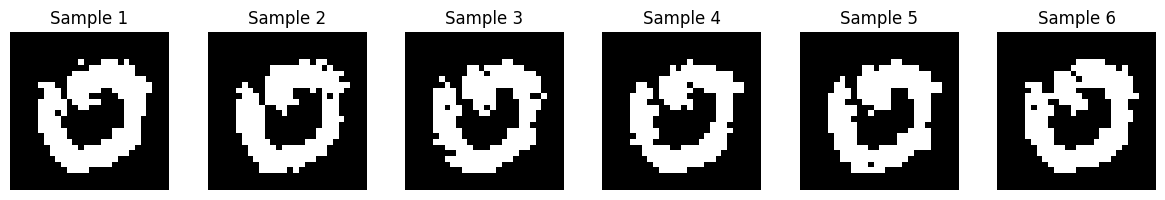

In [5]:
# Validating that dynamic binarization works

dataset =  train_loader.dataset
idx = 42  # Change if you want to visualize a different sample

samples = [dataset[idx][0] for _ in range(6)]  # Sample same image 6 times

# Plot the different binarizations
fig, axs = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axs[i].imshow(samples[i].view(28, 28), cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f"Sample {i+1}")
plt.tight_layout()
plt.show()

# Define models

In [6]:
class MarkovTransition(nn.Module): # p_t(z_t|z_s)
    def __init__(self, latent_dim=64, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, 2 * latent_dim)
        )
        self.var_offset = 1e-4

    def forward(self, x_in):
        mu, log_var = self.net(x_in).chunk(2, dim=-1)
        var = log_var.exp() + self.var_offset
        return mu, torch.sqrt(var)

class Decoder(nn.Module): # p(x|z) logits
    def __init__(self, latent_dim=64, hidden_dim=512, output_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, output_dim)
        )
        self.latent_dim = latent_dim
        self.logit_clamp=11.51 # logit(1e-5)

    def forward(self, z):
        logits = self.net(z)
        logits = logits.clamp(min=-self.logit_clamp, max=self.logit_clamp)
        return logits  # [B, 784]

class MarkovEncoder(nn.Module): # q_t(z_t|z_s)
    def __init__(self, input_dim=784, latent_dim=64, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + latent_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, 2 * latent_dim)
        )
        self.var_offset = 1e-4

    def forward(self, x):
        mu, log_var = self.net(x).chunk(2, dim=-1)
        var = log_var.exp() + self.var_offset
        return mu, torch.sqrt(var)

In [7]:
class hierarchical_VAE(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=512, dropout_prob=0.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.device = device

        self.encoder = MarkovEncoder(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.transition = MarkovTransition(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.decoder = Decoder(latent_dim=latent_dim)

    def p(self, z_prev, t):
        inp = torch.cat([z_prev, t], dim=-1)
        mu, sigma = self.transition(inp)
        return mu, sigma

    def q(self, x_flat, z_prev, t):
        inp = torch.cat([x_flat, z_prev, t], dim=-1)
        mu, sigma = self.encoder(inp)
        return mu, sigma

    def elbo(self, x, t_grid, kl_scale=1.0, return_parts=False):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        T = len(t_grid)
        T_tensor = torch.full((B, 1), float(T), device=self.device)

        kl_per_step = []

        # Prior at t=0
        t0 = t_grid[0].expand(B, 1)
        mu_q0, sigma_q0 = self.q(x_flat, torch.zeros(B, self.latent_dim, device=self.device),t0)
        q0 = Normal(mu_q0, sigma_q0)
        p0 = Normal(torch.zeros_like(mu_q0), torch.ones_like(sigma_q0))
        kl0 = kl_divergence(q0, p0).sum(-1).mean()
        kl_per_step.append(kl0.item())

        z = mu_q0 + sigma_q0 * torch.randn_like(mu_q0)
        kl_transition = 0.0

        for idx in range(1, T):
            t = t_grid[idx].expand(B, 1)

            mu_q, sigma_q = self.q(x_flat, z, t)
            mu_p, sigma_p = self.p(z, t)

            q_dist = Normal(mu_q, sigma_q)
            p_dist = Normal(mu_p, sigma_p)

            kl_t = kl_divergence(q_dist, p_dist).sum(-1).mean()
            kl_per_step.append(kl_t.item())
            kl_transition += kl_t

            z = mu_q + sigma_q * torch.randn_like(mu_q)

        logits = self.decoder(z)
        recon = -F.binary_cross_entropy_with_logits(logits, x_flat, reduction='sum') / B

        kl_total = kl0 + kl_transition
        elbo = recon - kl_scale * kl_total

        if return_parts:
            return elbo, recon.item(), kl_total.item(), kl_per_step
        else:
            return elbo

    @torch.no_grad()
    def generate_samples(self, num_samples=64, t_grid=range(1, 2)):
        """
        Draw samples from p_t(z_t|z_{t-1}) starting from prior z_0 ~ N(0,I).
        """
        z = torch.randn(num_samples, self.latent_dim, device=self.device)
        T = len(t_grid)

        for idx in range(1, T):
            t = t_grid[idx].expand(num_samples, 1)
            mu_p, sigma_p = self.p(z, t)
            z = mu_p + sigma_p * torch.randn_like(mu_p)

        logits = self.decoder(z)
        probs = torch.sigmoid(logits)
        x_samples = torch.bernoulli(probs)
        return x_samples.view(-1, 1, 28, 28)

    @torch.no_grad()
    def evaluate_elbo(self, data_loader, t_grid, return_parts=False):
        """
        Evaluate mean ELBO (and optionally recon, KL total, and KL curves) over a dataset.
        """
        self.eval()
        total_elbo = 0.0
        total_recon = 0.0
        total_kl = 0.0
        all_kl_curves = []

        n = 0
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(self.device)
            B = x_batch.shape[0]

            if return_parts:
                elbo_batch, recon_batch, kl_total_batch, kl_curve = self.elbo(
                    x_batch, t_grid, return_parts=True
                )
                total_recon += recon_batch * B
                total_kl += kl_total_batch * B
                all_kl_curves.append(kl_curve)
            else:
                elbo_batch = self.elbo(x_batch, t_grid)

            total_elbo += elbo_batch.item() * B
            n += B

        mean_elbo = total_elbo / n
        if return_parts:
            mean_recon = total_recon / n
            mean_kl = total_kl / n
            mean_kl_curve = torch.tensor(all_kl_curves).mean(dim=0).tolist()
            return mean_elbo, mean_recon, mean_kl, mean_kl_curve
        else:
            return mean_elbo

    def iwae(self, x, t_grid, K=50):
        """
        Compute IWAE bound for a batch of data y with K importance samples.
        Markov q(z_t|z_{t-1}, x).
        Args:
            x: [B, …] (original data, e.g. images)
            t_grid: [T] tensor of timepoints in [0,1]
            K: number of importance samples
        """
        B = x.shape[0]
        x_flat = x.view(B, -1)  # flatten

        T = len(t_grid)

        # Repeat y for K importance samples
        x_flat = x_flat.unsqueeze(1).repeat(1, K, 1).view(B * K, -1)
        T_tensor = torch.full((B * K, 1), float(T), device=self.device)

        # ---- Step t=0 ----
        t0 = t_grid[0].expand(B * K, 1)
        mu_q0, sigma_q0 = self.q(
            x_flat, torch.zeros(B * K, self.latent_dim, device=self.device),
            t0
        )
        eps0 = torch.randn_like(mu_q0)
        z = mu_q0 + sigma_q0 * eps0

        q_logprob = Normal(mu_q0, sigma_q0).log_prob(z).sum(-1)
        p_logprob = Normal(torch.zeros_like(mu_q0), torch.ones_like(sigma_q0)).log_prob(z).sum(-1)

        log_w = p_logprob - q_logprob  # [B*K]

        # ---- Steps t=1,...,T-1 ----
        for idx in range(1, T):
            t = t_grid[idx].expand(B * K, 1)

            mu_q, sigma_q = self.q(x_flat, z, t)
            eps = torch.randn_like(mu_q)
            z_new = mu_q + sigma_q * eps

            mu_p, sigma_p = self.p(z, t) # , T_tensor)

            q_logprob = Normal(mu_q, sigma_q).log_prob(z_new).sum(-1)
            p_logprob = Normal(mu_p, sigma_p).log_prob(z_new).sum(-1)

            log_w += p_logprob - q_logprob
            z = z_new

        # ---- Final decoding ----
        #z_T = torch.cat([z, T_tensor], dim=-1)
        logits = self.decoder(z) #z_T)
        recon_logprob = -F.binary_cross_entropy_with_logits(
            logits, x_flat, reduction='none'
        ).sum(-1)

        log_w += recon_logprob

        # ---- IWAE bound ----
        log_w = log_w.view(B, K)
        iwae_bound = torch.logsumexp(log_w, dim=1) - np.log(K)
        return iwae_bound.mean()

    @torch.no_grad()
    def evaluate_iwae_bound(self, data_loader, t_grid, K=50):
        """
        Evaluate mean IWAE bound over a dataset.
        """
        self.eval()
        total_iwae = 0.0
        n = 0
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(self.device)
            B = x_batch.shape[0]
            iwae_batch = self.iwae(x_batch, t_grid, K=K)
            total_iwae += iwae_batch.item() * B
            n += B
        return total_iwae / n



# Training loop (Task 1.2)

lr=0.00010 n_epochs=10 warmup_epochs=5


wandb: Currently logged in as: last24ag (last24ag-copenhagen-business-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch   0 | ELBO: -254.802 | Validation ELBO: -1503.540
Epoch   1 | ELBO: -139.100 | Validation ELBO: -158.926
Epoch   2 | ELBO: -118.211 | Validation ELBO: -136.870
Epoch   3 | ELBO: -118.465 | Validation ELBO: -129.529
Epoch   4 | ELBO: -120.343 | Validation ELBO: -124.572
Epoch   5 | ELBO: -122.539 | Validation ELBO: -121.819
Epoch   6 | ELBO: -120.226 | Validation ELBO: -119.587
Epoch   7 | ELBO: -118.348 | Validation ELBO: -118.333
Epoch   8 | ELBO: -116.860 | Validation ELBO: -116.756
Epoch   9 | ELBO: -115.509 | Validation ELBO: -115.567


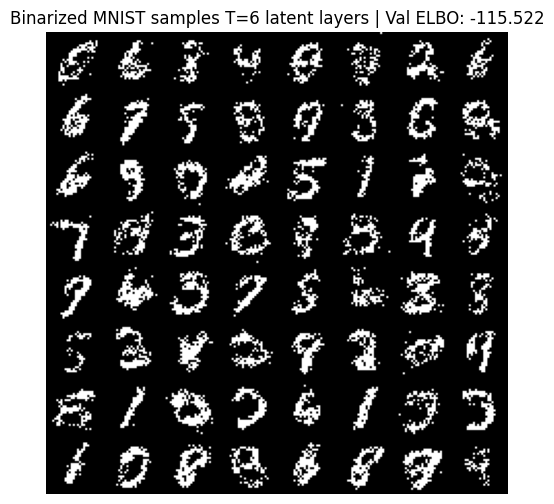

epoch,▁▂▃▃▄▅▆▆▇█
kl_warmup_factor,▁▂▄▅▇█████
train_elbo,▁▇████████
val_elbo,▁█████████
val_elbo_final,▁
epoch,9
kl_warmup_factor,1
train_elbo,-115.50947
val_elbo,-115.5673
val_elbo_final,-115.52169


In [ ]:
import matplotlib.pyplot as plt

model = hierarchical_VAE(latent_dim=100, hidden_dim=784).to(device)

T = 5 # number of latent layers
T_grid = torch.linspace(0, 1, T, device=device)

lr = 1e-4  # Reduced learning rate to prevent NaN
n_epochs = 10
warmup_epochs = 5

print(f"lr={lr:.5f} n_epochs={n_epochs} warmup_epochs={warmup_epochs}")

# Initialize wandb
wandb.init(
    project="hierarchical-vae-mnist",
    config={
        "latent_dim": 100,
        "hidden_dim": 784,
        "T": T,
        "lr": lr,
        "n_epochs": n_epochs,
        "warmup_epochs": warmup_epochs,
        "batch_size": train_loader.batch_size,
    }
)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

for epoch in range(n_epochs):
    scale = kl_warmup_factor(epoch, warmup_epochs=warmup_epochs, schedule="linear")
    epoch_loss = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        loss = -model.elbo(x_batch, T_grid, kl_scale=scale)
        
        # Check for NaN and skip batch if detected
        if torch.isnan(loss):
            print(f"Warning: NaN loss detected at epoch {epoch}, skipping batch")
            continue
            
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()

    train_elbo = -epoch_loss/len(train_loader)
    val_elbo = model.evaluate_elbo(val_loader, T_grid)
    
    # Log metrics to wandb
    wandb.log({
        "epoch": epoch,
        "train_elbo": train_elbo,
        "val_elbo": val_elbo,
        "kl_warmup_factor": scale,
    })
    
    print(f"Epoch {epoch:3d} | ELBO: {train_elbo:.3f} | Validation ELBO: {val_elbo:.3f}")

# Generate samples
val_elbo_final = model.evaluate_elbo(val_loader, T_grid)
#val_iwae_final = model.evaluate_iwae_bound(val_loader, T_grid)
samples = model.generate_samples(64, T_grid).cpu()

# Visualize
grid = torch.cat([torch.cat([samples[i * 8 + j] for j in range(8)], dim=-1) for i in range(8)], dim=-2)
plt.figure(figsize=(6, 6))
plt.imshow(grid.squeeze(0), cmap="gray")
plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f}")
#plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f} | Val IWAE: {val_iwae_final:.3f}")
plt.axis("off")
plt.show()

# Log final metrics and generated samples to wandb
wandb.log({
    "val_elbo_final": val_elbo_final,
    "generated_samples": wandb.Image(grid.squeeze(0).numpy(), caption=f"T={T} layers")
})

wandb.finish()

# Training loop (Task 1.3)

lr=0.00010 n_epochs=100 warmup_epochs=5


Epoch   0 | ELBO: -253.958 | Validation ELBO: -835.666
Epoch   1 | ELBO: -128.514 | Validation ELBO: -153.267
Epoch   2 | ELBO: -113.587 | Validation ELBO: -134.489
Epoch   3 | ELBO: -114.791 | Validation ELBO: -127.494
Epoch   4 | ELBO: -117.738 | Validation ELBO: -122.982
Epoch   5 | ELBO: -120.947 | Validation ELBO: -120.543
Epoch   6 | ELBO: -118.959 | Validation ELBO: -118.758
Epoch   7 | ELBO: -117.491 | Validation ELBO: -117.363
Epoch   8 | ELBO: -116.035 | Validation ELBO: -116.256
Epoch   9 | ELBO: -114.991 | Validation ELBO: -115.149
Epoch  10 | ELBO: -113.972 | Validation ELBO: -114.308
Epoch  11 | ELBO: -113.051 | Validation ELBO: -113.311
Epoch  12 | ELBO: -112.095 | Validation ELBO: -112.544
Epoch  13 | ELBO: -111.429 | Validation ELBO: -111.697
Epoch  14 | ELBO: -110.686 | Validation ELBO: -111.309
Epoch  15 | ELBO: -109.923 | Validation ELBO: -110.516
Epoch  16 | ELBO: -109.341 | Validation ELBO: -109.727
Epoch  17 | ELBO: -108.615 | Validation ELBO: -109.295
Epoch  18 

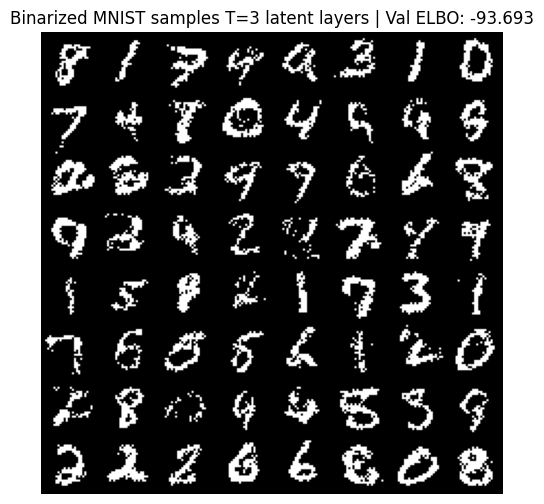

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
kl_warmup_factor,▁███████████████████████████████████████
train_elbo,▁▄▃▃▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████
val_elbo,▁▂▃▃▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
val_elbo_final,▁
epoch,99
kl_warmup_factor,1
train_elbo,-92.45882
val_elbo,-93.84976
val_elbo_final,-93.69267


In [ ]:
model = hierarchical_VAE(latent_dim=100, hidden_dim=784).to(device)

T = 3 # Keep this fixed to 3 this time
T_grid = torch.linspace(0, 1, T, device=device)

lr = 1e-4  
n_epochs = 100 # Increased from 10 up to 100
warmup_epochs = 10 # Increased from 5 to 20

print(f"lr={lr:.5f} n_epochs={n_epochs} warmup_epochs={warmup_epochs}")

# Initialize wandb
wandb.init(
    project="hierarchical-vae-mnist",
    config={
        "latent_dim": 100,
        "hidden_dim": 784,
        "T": T,
        "lr": lr,
        "n_epochs": n_epochs,
        "warmup_epochs": warmup_epochs,
        "batch_size": train_loader.batch_size,
    }
)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

for epoch in range(n_epochs):
    scale = kl_warmup_factor(epoch, warmup_epochs=warmup_epochs, schedule="linear")
    epoch_loss = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        loss = -model.elbo(x_batch, T_grid, kl_scale=scale)
        
        # Check for NaN and skip batch if detected
        if torch.isnan(loss):
            print(f"Warning: NaN loss detected at epoch {epoch}, skipping batch")
            continue
            
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()

    train_elbo = -epoch_loss/len(train_loader)
    val_elbo = model.evaluate_elbo(val_loader, T_grid)
    
    # Log metrics to wandb
    wandb.log({
        "epoch": epoch,
        "train_elbo": train_elbo,
        "val_elbo": val_elbo,
        "kl_warmup_factor": scale,
    })
    
    print(f"Epoch {epoch:3d} | ELBO: {train_elbo:.3f} | Validation ELBO: {val_elbo:.3f}")

# Generate samples
val_elbo_final = model.evaluate_elbo(val_loader, T_grid)
#val_iwae_final = model.evaluate_iwae_bound(val_loader, T_grid)
samples = model.generate_samples(64, T_grid).cpu()

# Visualize
grid = torch.cat([torch.cat([samples[i * 8 + j] for j in range(8)], dim=-1) for i in range(8)], dim=-2)
plt.figure(figsize=(6, 6))
plt.imshow(grid.squeeze(0), cmap="gray")
plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f}")
#plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f} | Val IWAE: {val_iwae_final:.3f}")
plt.axis("off")
plt.show()

# Log final metrics and generated samples to wandb
wandb.log({
    "val_elbo_final": val_elbo_final,
    "generated_samples": wandb.Image(grid.squeeze(0).numpy(), caption=f"T={T} layers")
})

wandb.finish()

# Task 1.4: Compute IWAE bound for the trained model


Task 1.4: Computing IWAE Bound
Using trained model from Task 1.3 with T=3


Validation ELBO: -93.730

Computing IWAE with K=50 importance samples (REPORT VALUE)...
Validation IWAE (K=50): -89.228

Sanity-check: Computing IWAE with K=10...
Validation IWAE (K=10): -90.362

Sanity-check: Computing IWAE with K=100...
Validation IWAE (K=100): -88.958

Task 1.4 Summary (report-ready)
T (latent layers):              3
Training warm-up epochs (1.3):  5
Training total epochs (1.3):    100
Validation ELBO:                -93.730
Validation IWAE (K=50):        -89.228
IWAE–ELBO gap (K=50):          4.502
Sanity IWAE (K=10):                  -90.362
Sanity IWAE (K=100):                  -88.958


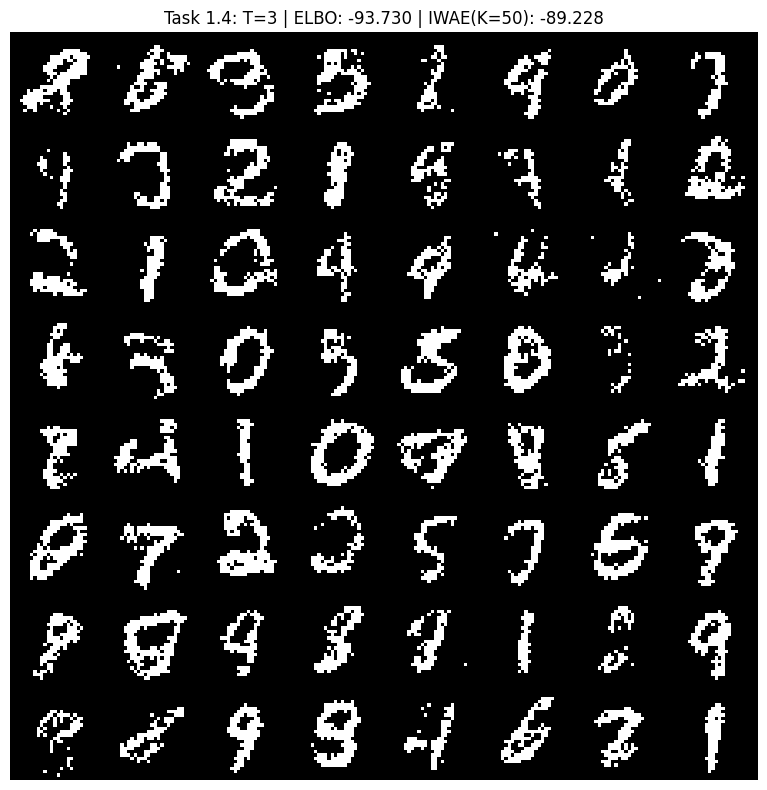

task_1.4_iwae_elbo_gap,▁
task_1.4_val_elbo,▁
task_1.4_val_iwae_K10,▁
task_1.4_val_iwae_K100,▁
task_1.4_val_iwae_K50,▁
task_1.4_val_iwae_report,▁
task_1.4_iwae_elbo_gap,4.50202
task_1.4_val_elbo,-93.73001
task_1.4_val_iwae_K10,-90.36202
task_1.4_val_iwae_K100,-88.95825
task_1.4_val_iwae_K50,-89.22799


In [ ]:
print("\nTask 1.4: Computing IWAE Bound")
print(f"Using trained model from Task 1.3 with T={T}")

# Task 1.4 is EVALUATION ONLY.
# We do NOT train here, so we only log the training metadata from Task 1.3
# (epochs/warmup) for context.
trained_n_epochs = 100             # NEW: carry over from Task 1.3 run
trained_warmup_epochs = 10   # NEW: carry over from Task 1.3 run

# Choose one K to report (Task 1.4 requirement)
K_report = 50  

# For sanity-check Ks 
K_sanity = [10, 100]  

# Initialize wandb for Task 1.4 (same project, same metrics style)
wandb.init(
    project="hierarchical-vae-mnist",
    name=f"task_1.4_IWAE_T{T}",
    config={
        "task": "1.4_iwae_evaluation",
        "T": T,
        "latent_dim": 100,
        "hidden_dim": 784,
        # NEW: log Task 1.3 training metadata (NOT Task 1.4 settings)
        "trained_warmup_epochs": trained_warmup_epochs,
        "trained_total_epochs": trained_n_epochs,
        # NEW: log which K is the one you report
        "IWAE_K_report": K_report,
        # NEW: log which Ks you optionally sanity-check
        "IWAE_K_sanity": K_sanity,
    },
)

# Compute ELBO baseline
val_elbo = model.evaluate_elbo(val_loader, T_grid)
print(f"Validation ELBO: {val_elbo:.3f}")


# Compute IWAE for reported K
print(f"\nComputing IWAE with K={K_report} importance samples (REPORT VALUE)...")
val_iwae_report = model.evaluate_iwae_bound(val_loader, T_grid, K=K_report)
print(f"Validation IWAE (K={K_report}): {val_iwae_report:.3f}")

# Log the main values (this is what you use in the write-up)
wandb.log({
    "task_1.4_val_elbo": val_elbo,
    f"task_1.4_val_iwae_K{K_report}": val_iwae_report,
    "task_1.4_iwae_elbo_gap": val_iwae_report - val_elbo,
})


# Optional: sanity-check a couple other K's
iwae_sanity_results = {}  # NEW
for K in K_sanity:
    print(f"\nSanity-check: Computing IWAE with K={K}...")
    val_iwae = model.evaluate_iwae_bound(val_loader, T_grid, K=K)
    iwae_sanity_results[K] = val_iwae
    print(f"Validation IWAE (K={K}): {val_iwae:.3f}")

    # Log as separate scalar metrics (keeps W&B clean)
    wandb.log({f"task_1.4_val_iwae_K{K}": val_iwae})


# Print report summary
print(f"\n{'='*60}")
print("Task 1.4 Summary (report-ready)")
print(f"{'='*60}")
print(f"T (latent layers):              {T}")
print(f"Training warm-up epochs (1.3):  {trained_warmup_epochs}")
print(f"Training total epochs (1.3):    {trained_n_epochs}")
print(f"Validation ELBO:                {val_elbo:.3f}")
print(f"Validation IWAE (K={K_report}):        {val_iwae_report:.3f}")
print(f"IWAE–ELBO gap (K={K_report}):          {val_iwae_report - val_elbo:.3f}")
for K in K_sanity:
    print(f"Sanity IWAE (K={K}):                  {iwae_sanity_results[K]:.3f}")
print(f"{'='*60}")

# Generate samples
# NOTE: Sampling does NOT depend on IWAE; IWAE is only an evaluation bound.
# I still log samples for completeness and to match prior W&B logging style.

samples = model.generate_samples(64, T_grid).cpu()
grid = torch.cat(
    [torch.cat([samples[i * 8 + j] for j in range(8)], dim=-1) for i in range(8)],
    dim=-2,
)

plt.figure(figsize=(8, 8))
plt.imshow(grid.squeeze(0), cmap="gray")
plt.title(
    f"Task 1.4: T={T} | ELBO: {val_elbo:.3f} | IWAE(K={K_report}): {val_iwae_report:.3f}"
)
plt.axis("off")
plt.tight_layout()
plt.show()

wandb.log({
    "task_1.4_generated_samples": wandb.Image(
        grid.squeeze(0).numpy(),
        caption=f"T={T} | ELBO={val_elbo:.3f} | IWAE(K={K_report})={val_iwae_report:.3f}",
    ),
    # Also log a single final scalar for convenience
    "task_1.4_val_iwae_report": val_iwae_report,
})

wandb.finish()


# Task 1.5

In [22]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, kl_divergence

# =====================================================================
# Task 1.5 (SDE-style) VARIANT — RENAMED so you can keep the originals
#
# Slide-inspired parameterization:
#   mu_{θ,t}(z) = z + f(z,t) Δt
#   mu_{φ,t}(x,z) = z + g(x,z,t) Δt
#   σ_{θ,t}(z) = σ_{φ,t}(...) = σ(·,t) sqrt(Δt)
# with Δt = 1/(T-1)
#
# IMPORTANT:
# - Only the NEW classes/functions are renamed.
# =====================================================================

class MarkovTransitionSDE(nn.Module):  # NEW 
    """SDE-style transition for p_t(z_t | z_{t-1})."""

    def __init__(self, latent_dim=64, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.var_offset = 1e-4

    def forward(self, z_prev, t, dt):
        """Returns (mu, sigma) using residual mean and sqrt(dt) scaling."""
        x_in = torch.cat([z_prev, t], dim=-1)
        drift, log_var = self.net(x_in).chunk(2, dim=-1)

        var_base = log_var.exp() + self.var_offset
        sigma_base = torch.sqrt(var_base)

        mu = z_prev + drift * dt
        sigma = sigma_base * math.sqrt(dt)
        return mu, sigma


class MarkovEncoderSDE(nn.Module):  # NEW 
    """SDE-style encoder for q_t(z_t | z_{t-1}, x)."""

    def __init__(self, input_dim=784, latent_dim=64, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + latent_dim + 1, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )
        self.var_offset = 1e-4

    def forward(self, x_flat, z_prev, t, dt):
        """Returns (mu, sigma) using residual mean and sqrt(dt) scaling."""
        x_in = torch.cat([x_flat, z_prev, t], dim=-1)
        drift, log_var = self.net(x_in).chunk(2, dim=-1)

        var_base = log_var.exp() + self.var_offset
        sigma_base = torch.sqrt(var_base)

        mu = z_prev + drift * dt
        sigma = sigma_base * math.sqrt(dt)
        return mu, sigma


class hierarchical_VAE_SDE(nn.Module):  # NEW
    """Drop-in alternative to hierarchical_VAE using SDE-style parameterization."""

    def __init__(self, latent_dim=64, hidden_dim=512, dropout_prob=0.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.device = device

        # Use SDE variants here
        self.encoder = MarkovEncoderSDE(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.transition = MarkovTransitionSDE(latent_dim=latent_dim, hidden_dim=hidden_dim)

        # Decoder is unchanged
        self.decoder = Decoder(latent_dim=latent_dim)

    @staticmethod
    def _dt_from_tgrid(t_grid):
        """Δt = 1/(T-1) (safe for T=1)."""
        T = len(t_grid)
        return 1.0 / max(T - 1, 1)

    
    # SDE-style p and q
    def p(self, z_prev, t, dt):
        return self.transition(z_prev, t, dt)

    def q(self, x_flat, z_prev, t, dt):
        return self.encoder(x_flat, z_prev, t, dt)

    # ELBO (same logic)
    def elbo(self, x, t_grid, kl_scale=1.0, return_parts=False):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        T = len(t_grid)
        dt = self._dt_from_tgrid(t_grid)

        kl_per_step = []

        # Prior at t=0
        t0 = t_grid[0].expand(B, 1)
        z0_prev = torch.zeros(B, self.latent_dim, device=self.device)

        mu_q0, sigma_q0 = self.q(x_flat, z0_prev, t0, dt)
        q0 = Normal(mu_q0, sigma_q0)
        p0 = Normal(torch.zeros_like(mu_q0), torch.ones_like(sigma_q0))
        kl0 = kl_divergence(q0, p0).sum(-1).mean()
        kl_per_step.append(kl0.item())

        z = mu_q0 + sigma_q0 * torch.randn_like(mu_q0)
        kl_transition = 0.0

        for idx in range(1, T):
            t = t_grid[idx].expand(B, 1)

            mu_q, sigma_q = self.q(x_flat, z, t, dt)
            mu_p, sigma_p = self.p(z, t, dt)

            q_dist = Normal(mu_q, sigma_q)
            p_dist = Normal(mu_p, sigma_p)

            kl_t = kl_divergence(q_dist, p_dist).sum(-1).mean()
            kl_per_step.append(kl_t.item())
            kl_transition += kl_t

            z = mu_q + sigma_q * torch.randn_like(mu_q)

        logits = self.decoder(z)
        recon = -F.binary_cross_entropy_with_logits(logits, x_flat, reduction="sum") / B

        kl_total = kl0 + kl_transition
        elbo = recon - kl_scale * kl_total

        if return_parts:
            return elbo, recon.item(), kl_total.item(), kl_per_step
        return elbo

    # Sampling
    @torch.no_grad()
    def generate_samples(self, num_samples=64, t_grid=range(1, 2)):
        z = torch.randn(num_samples, self.latent_dim, device=self.device)
        T = len(t_grid)
        dt = 1.0 / max(T - 1, 1)

        for idx in range(1, T):
            t = t_grid[idx].expand(num_samples, 1)
            mu_p, sigma_p = self.p(z, t, dt)
            z = mu_p + sigma_p * torch.randn_like(mu_p)

        logits = self.decoder(z)
        probs = torch.sigmoid(logits)
        x_samples = torch.bernoulli(probs)
        return x_samples.view(-1, 1, 28, 28)

    # Evaluation helpers
    @torch.no_grad()
    def evaluate_elbo(self, data_loader, t_grid, return_parts=False):
        self.eval()
        total_elbo = 0.0
        total_recon = 0.0
        total_kl = 0.0
        all_kl_curves = []

        n = 0
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(self.device)
            B = x_batch.shape[0]

            if return_parts:
                elbo_batch, recon_batch, kl_total_batch, kl_curve = self.elbo(
                    x_batch, t_grid, return_parts=True
                )
                total_recon += recon_batch * B
                total_kl += kl_total_batch * B
                all_kl_curves.append(kl_curve)
            else:
                elbo_batch = self.elbo(x_batch, t_grid)

            total_elbo += elbo_batch.item() * B
            n += B

        mean_elbo = total_elbo / n
        if return_parts:
            mean_recon = total_recon / n
            mean_kl = total_kl / n
            mean_kl_curve = torch.tensor(all_kl_curves).mean(dim=0).tolist()
            return mean_elbo, mean_recon, mean_kl, mean_kl_curve
        return mean_elbo

    
    # IWAE (same logic)
    def iwae(self, x, t_grid, K=50):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        T = len(t_grid)
        dt = self._dt_from_tgrid(t_grid)

        x_flat = x_flat.unsqueeze(1).repeat(1, K, 1).view(B * K, -1)

        # t=0
        t0 = t_grid[0].expand(B * K, 1)
        z0_prev = torch.zeros(B * K, self.latent_dim, device=self.device)
        mu_q0, sigma_q0 = self.q(x_flat, z0_prev, t0, dt)
        z = mu_q0 + sigma_q0 * torch.randn_like(mu_q0)

        q_logprob = Normal(mu_q0, sigma_q0).log_prob(z).sum(-1)
        p_logprob = Normal(torch.zeros_like(mu_q0), torch.ones_like(sigma_q0)).log_prob(z).sum(-1)
        log_w = p_logprob - q_logprob

        for idx in range(1, T):
            t = t_grid[idx].expand(B * K, 1)

            mu_q, sigma_q = self.q(x_flat, z, t, dt)
            z_new = mu_q + sigma_q * torch.randn_like(mu_q)

            mu_p, sigma_p = self.p(z, t, dt)

            q_logprob = Normal(mu_q, sigma_q).log_prob(z_new).sum(-1)
            p_logprob = Normal(mu_p, sigma_p).log_prob(z_new).sum(-1)

            log_w += p_logprob - q_logprob
            z = z_new

        logits = self.decoder(z)
        recon_logprob = -F.binary_cross_entropy_with_logits(logits, x_flat, reduction="none").sum(-1)
        log_w += recon_logprob

        log_w = log_w.view(B, K)
        iwae_bound = torch.logsumexp(log_w, dim=1) - np.log(K)
        return iwae_bound.mean()

    @torch.no_grad()
    def evaluate_iwae_bound(self, data_loader, t_grid, K=50):
        self.eval()
        total_iwae = 0.0
        n = 0
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(self.device)
            B = x_batch.shape[0]
            iwae_batch = self.iwae(x_batch, t_grid, K=K)
            total_iwae += iwae_batch.item() * B
            n += B
        return total_iwae / n


# --------------------------
# How to instantiate side-by-side
# --------------------------
# Original (unchanged):
#   model = hierarchical_VAE(latent_dim=100, hidden_dim=784).to(device)
# New SDE-style variant:
#   model_sde = hierarchical_VAE_SDE(latent_dim=100, hidden_dim=784).to(device)


lr=0.00010 n_epochs=100 warmup_epochs=10


Epoch   0 | ELBO: -55.451 | Validation ELBO: -747.430
Epoch   1 | ELBO: -63.935 | Validation ELBO: -111.690
Epoch   2 | ELBO: -66.017 | Validation ELBO: -103.596
Epoch   3 | ELBO: -70.063 | Validation ELBO: -99.819
Epoch   4 | ELBO: -73.735 | Validation ELBO: -97.504
Epoch   5 | ELBO: -77.283 | Validation ELBO: -95.971
Epoch   6 | ELBO: -80.604 | Validation ELBO: -95.097
Epoch   7 | ELBO: -83.711 | Validation ELBO: -94.433
Epoch   8 | ELBO: -86.594 | Validation ELBO: -93.876
Epoch   9 | ELBO: -89.416 | Validation ELBO: -93.666
Epoch  10 | ELBO: -92.021 | Validation ELBO: -93.358
Epoch  11 | ELBO: -91.922 | Validation ELBO: -93.491
Epoch  12 | ELBO: -91.843 | Validation ELBO: -93.233
Epoch  13 | ELBO: -91.790 | Validation ELBO: -93.248
Epoch  14 | ELBO: -91.795 | Validation ELBO: -92.911
Epoch  15 | ELBO: -91.642 | Validation ELBO: -93.039
Epoch  16 | ELBO: -91.594 | Validation ELBO: -93.055
Epoch  17 | ELBO: -91.586 | Validation ELBO: -92.911
Epoch  18 | ELBO: -91.464 | Validation ELBO

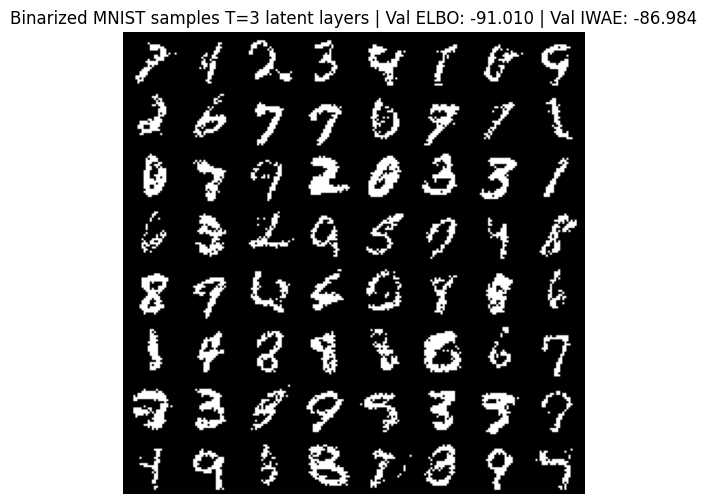

epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇████
kl_warmup_factor,▁▂▃▅▆▇██████████████████████████████████
train_elbo,█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂
val_elbo,▁▅▆▇▇▇▇▇▇▇▇███▇█████████████████████████
val_elbo_final,▁
epoch,99
kl_warmup_factor,1
train_elbo,-89.25482
val_elbo,-90.97827
val_elbo_final,-91.0102


In [23]:
model_sde = hierarchical_VAE_SDE(latent_dim=100, hidden_dim=784).to(device)

T = 3               # unchanged from 1.3 & 1.4
T_grid = torch.linspace(0, 1, T, device=device)

lr = 1e-4  
n_epochs = 100      # unchanged from 1.3 & 1.4
warmup_epochs = 10  # unchanged from 1.3 & 1.4

print(f"lr={lr:.5f} n_epochs={n_epochs} warmup_epochs={warmup_epochs}")

# Initialize wandb
wandb.init(
    project="hierarchical-vae-mnist",
    config={
        "latent_dim": 100,
        "hidden_dim": 784,
        "T": T,
        "lr": lr,
        "n_epochs": n_epochs,
        "warmup_epochs": warmup_epochs,
        "batch_size": train_loader.batch_size,
    }
)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

for epoch in range(n_epochs):
    scale = kl_warmup_factor(epoch, warmup_epochs=warmup_epochs, schedule="linear")
    epoch_loss = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        loss = -model.elbo(x_batch, T_grid, kl_scale=scale)
        
        # Check for NaN and skip batch if detected
        if torch.isnan(loss):
            print(f"Warning: NaN loss detected at epoch {epoch}, skipping batch")
            continue
            
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item()

    train_elbo = -epoch_loss/len(train_loader)
    val_elbo = model.evaluate_elbo(val_loader, T_grid)
    
    # Log metrics to wandb
    wandb.log({
        "epoch": epoch,
        "train_elbo": train_elbo,
        "val_elbo": val_elbo,
        "kl_warmup_factor": scale,
    })
    
    print(f"Epoch {epoch:3d} | ELBO: {train_elbo:.3f} | Validation ELBO: {val_elbo:.3f}")

# Generate samples
val_elbo_final = model.evaluate_elbo(val_loader, T_grid)
val_iwae_final = model.evaluate_iwae_bound(val_loader, T_grid)
samples = model.generate_samples(64, T_grid).cpu()

# Visualize
grid = torch.cat([torch.cat([samples[i * 8 + j] for j in range(8)], dim=-1) for i in range(8)], dim=-2)
plt.figure(figsize=(6, 6))
plt.imshow(grid.squeeze(0), cmap="gray")
# plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f}")
plt.title(f"Binarized MNIST samples T={T} latent layers | Val ELBO: {val_elbo_final:.3f} | Val IWAE: {val_iwae_final:.3f}")
plt.axis("off")
plt.show()

# Log final metrics and generated samples to wandb
wandb.log({
    "val_elbo_final": val_elbo_final,
    "generated_samples": wandb.Image(grid.squeeze(0).numpy(), caption=f"T={T} layers")
})

wandb.finish()